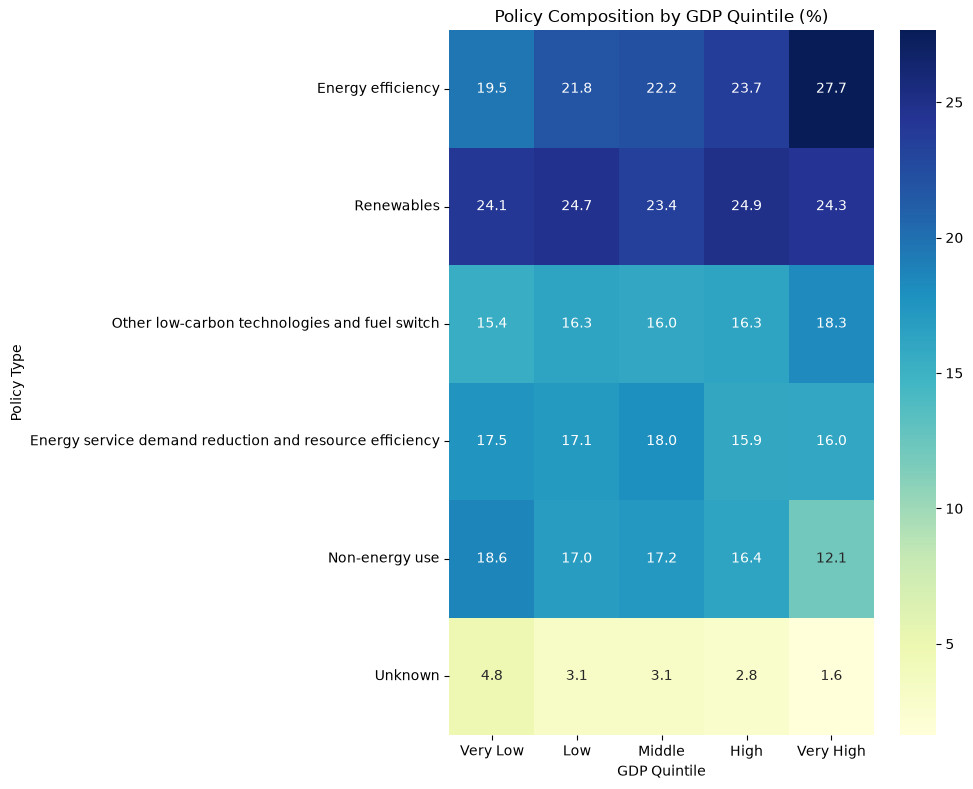

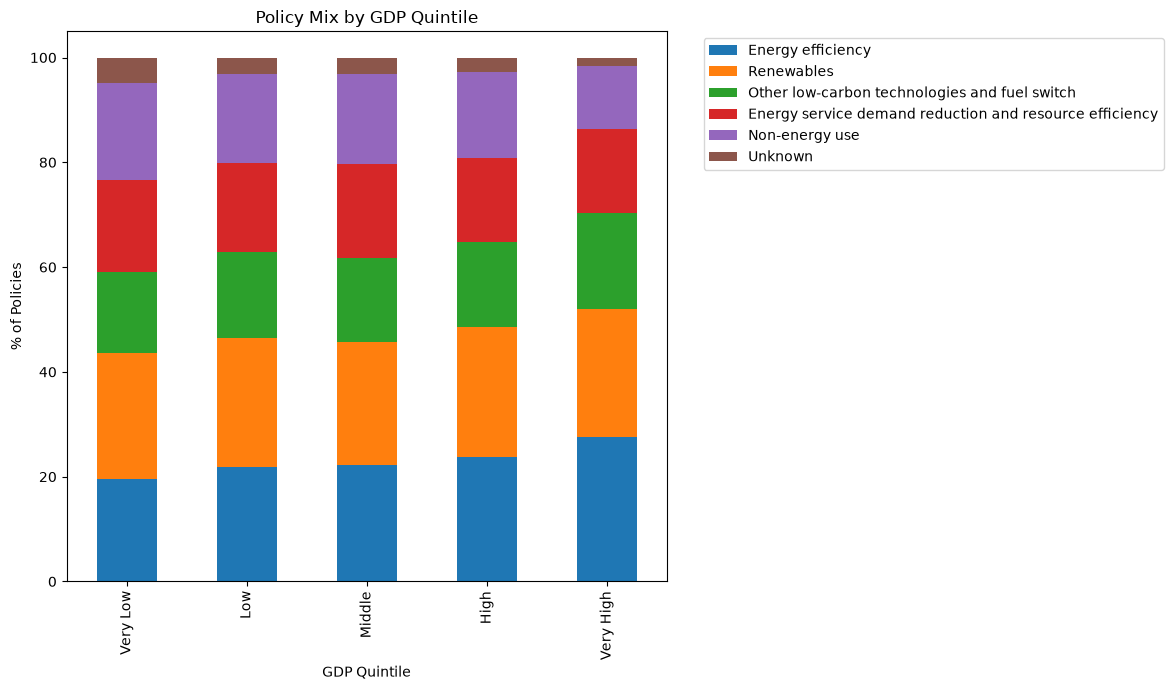

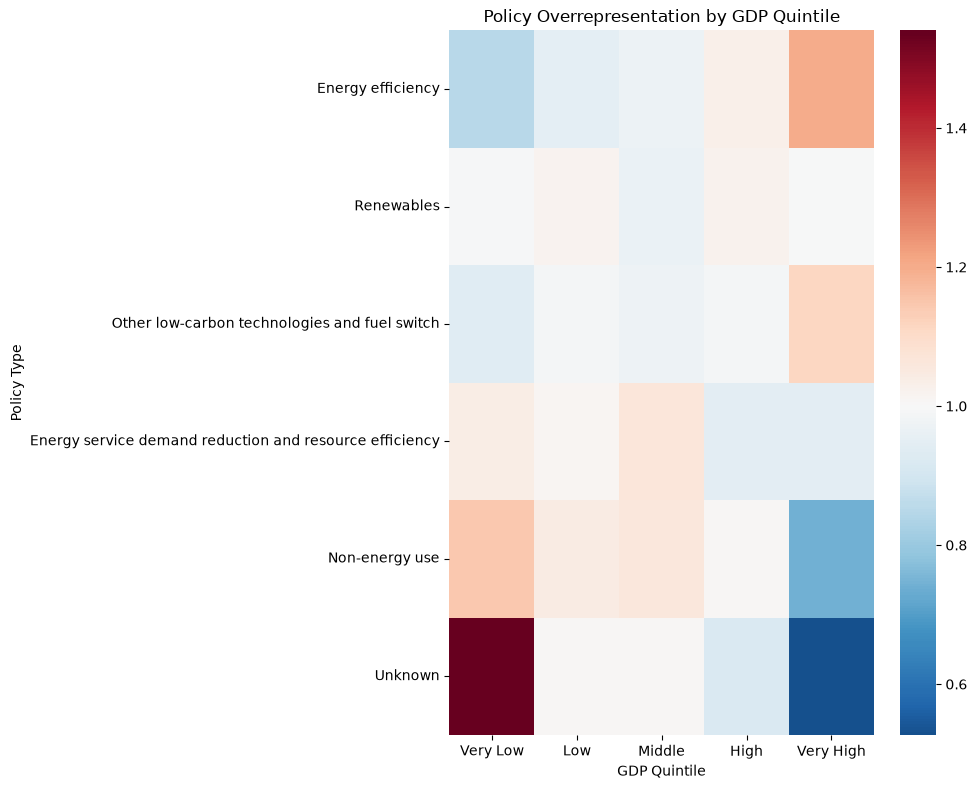

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================
# 1. GDP読み込み
# ==========================

gdp = pd.read_csv(
    "../../data/raw/GDP per capita/db9758b4-95e5-4584-b366-5dd38a5d3769_Data.csv"
)

year_cols = [c for c in gdp.columns if "[YR" in c]

gdp[year_cols] = (
    gdp[year_cols]
    .replace("..", np.nan)
    .apply(pd.to_numeric, errors="coerce")
)

country_gdp = (
    gdp
    .set_index("Country Code")[year_cols]
    .mean(axis=1)
    .reset_index()
)

country_gdp.columns = [
    "country_iso",
    "avg_gdp_pc"
]

# ==========================
# 2. GDPを5分位に分割
# ==========================

country_gdp["gdp_group"] = pd.qcut(
    country_gdp["avg_gdp_pc"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Middle",
        "High",
        "Very High"
    ]
)

# ==========================
# 3. CPDB読み込み
# ==========================

cpdb = pd.read_csv(
    "../../data/raw/cpdb_country_all.csv",
    low_memory=False
)

policy_gdp = cpdb.merge(
    country_gdp,
    on="country_iso",
    how="left"
)

# ==========================
# 4. policy_type展開
# ==========================

policy_gdp = policy_gdp.dropna(
    subset=["policy_type", "gdp_group"]
)

policy_gdp["policy_type"] = (
    policy_gdp["policy_type"]
    .astype(str)
    .str.replace("&amp;", "&", regex=False)
    .str.split(",")
)

policy_gdp = (
    policy_gdp
    .explode("policy_type")
    .reset_index(drop=True)
)

policy_gdp["policy_type"] = (
    policy_gdp["policy_type"]
    .str.strip()
)

policy_gdp = policy_gdp[
    policy_gdp["policy_type"] != ""
]

# ==========================
# 5. 集計
# ==========================

counts = (
    policy_gdp
    .groupby(
        ["policy_type", "gdp_group"]
    )
    .size()
    .unstack(fill_value=0)
)

# GDP階級ごとに100%
shares = counts.div(
    counts.sum(axis=0),
    axis=1
) * 100

# ==========================
# 6. 上位20カテゴリ
# ==========================

top_types = (
    policy_gdp["policy_type"]
    .value_counts()
    .head(20)
    .index
)

shares_top = shares.loc[top_types]

# ==========================
# 7. ヒートマップ
# ==========================

plt.figure(figsize=(10, 8))

sns.heatmap(
    shares_top,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f"
)

plt.title(
    "Policy Composition by GDP Quintile (%)"
)

plt.xlabel("GDP Quintile")
plt.ylabel("Policy Type")

plt.tight_layout()
plt.show()

# ==========================
# 8. 積み上げ棒グラフ
# ==========================

plot_df = shares_top.T

plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.ylabel("% of Policies")
plt.xlabel("GDP Quintile")

plt.title(
    "Policy Mix by GDP Quintile"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ==========================
# 9. GDPごとの特徴を強調
# ==========================

lift = shares.div(
    shares.mean(axis=1),
    axis=0
)

lift_top = lift.loc[top_types]

plt.figure(figsize=(10, 8))

sns.heatmap(
    lift_top,
    cmap="RdBu_r",
    center=1
)

plt.title(
    "Policy Overrepresentation by GDP Quintile"
)

plt.xlabel("GDP Quintile")
plt.ylabel("Policy Type")

plt.tight_layout()
plt.show()

In [12]:
policy_type_counts = (
    policy_gdp["policy_type"]
    .dropna()
    .astype(str)
    .str.replace("&amp;", "&", regex=False)
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

print(policy_type_counts)

policy_type
Energy efficiency                                          3482
Renewables                                                 3465
Other low-carbon technologies and fuel switch              2427
Energy service demand reduction and resource efficiency    2374
Non-energy use                                             2147
Unknown                                                     375
Name: count, dtype: int64


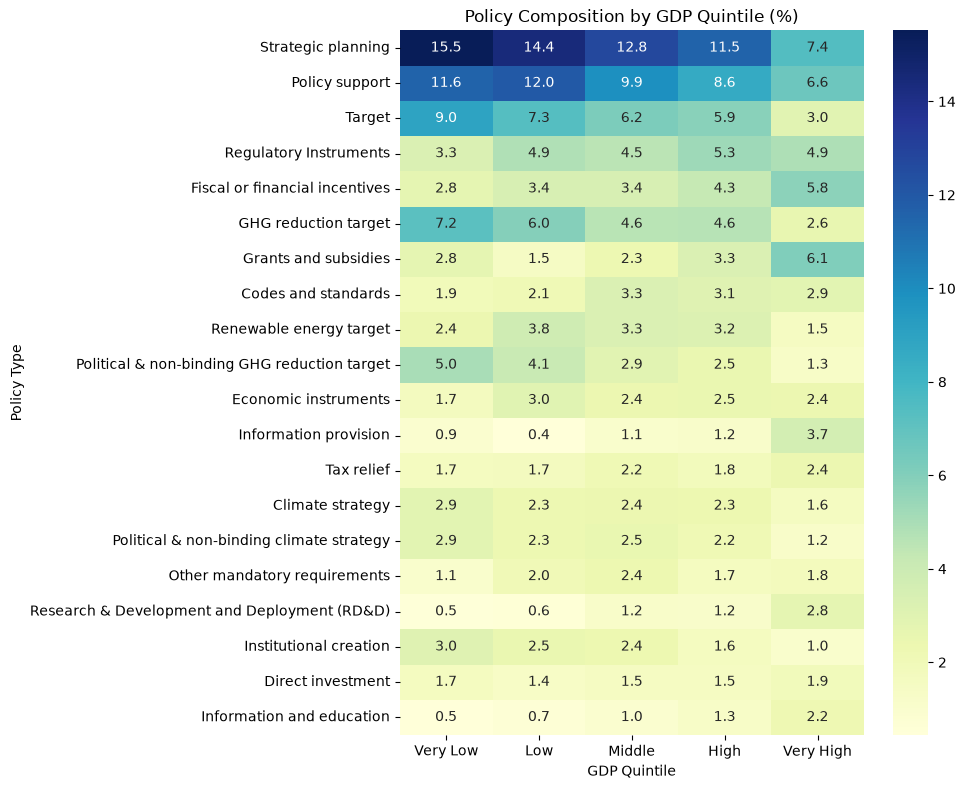

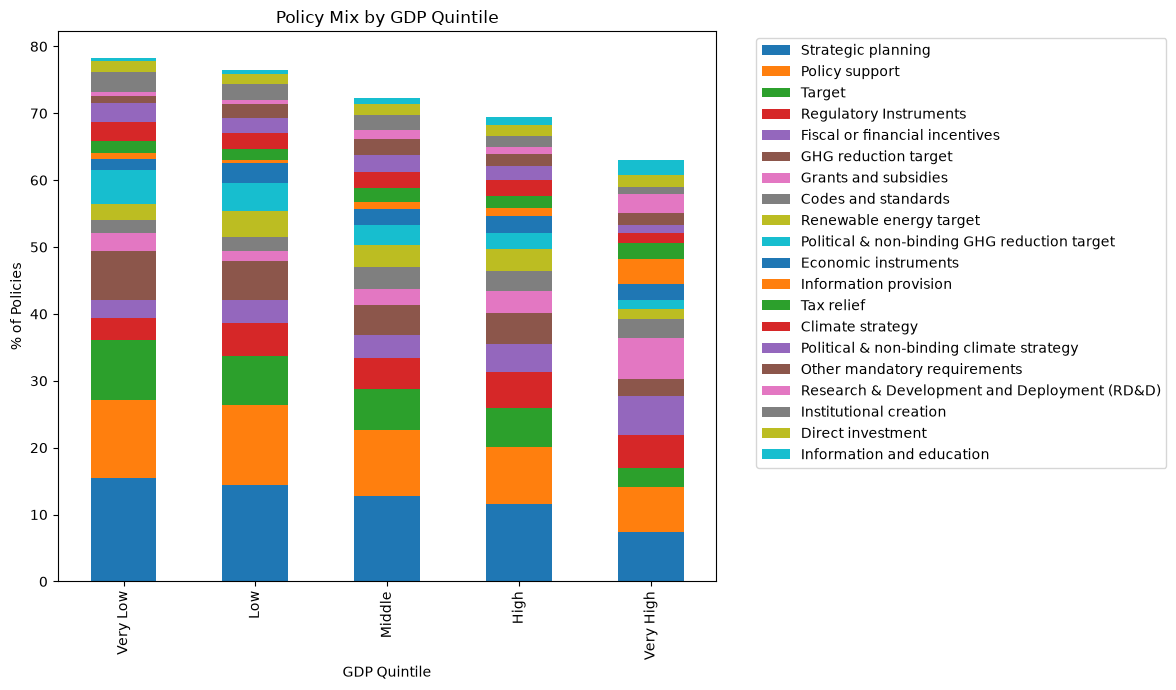

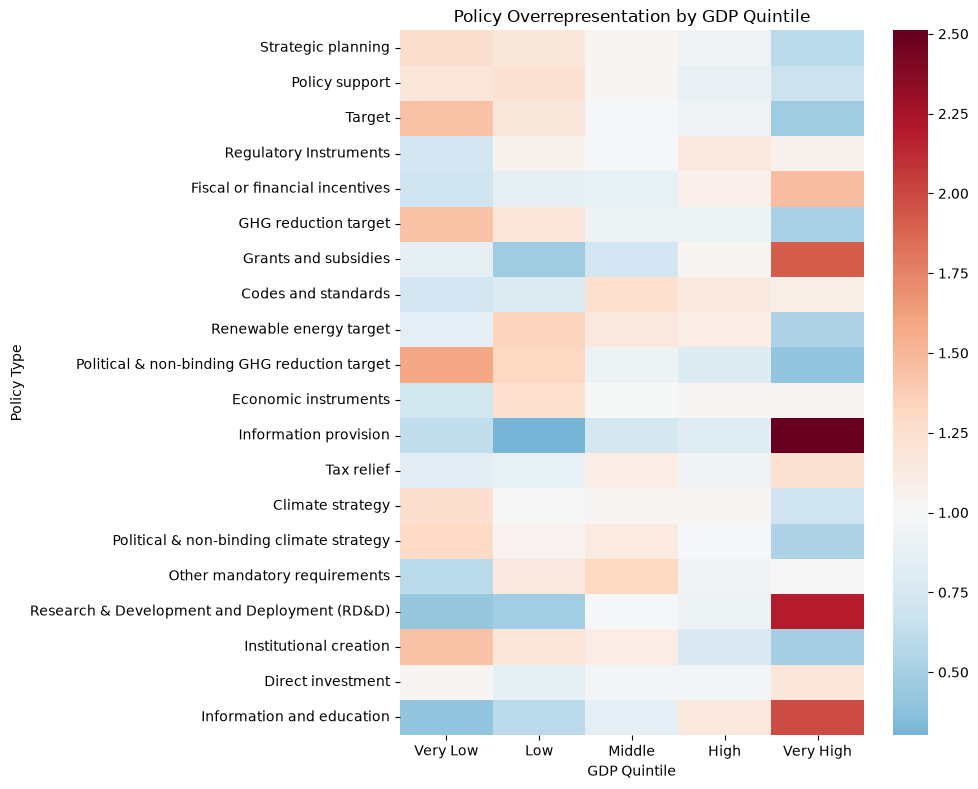

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================
# 1. GDP読み込み
# ==========================

gdp = pd.read_csv(
    "../../data/raw/GDP per capita/db9758b4-95e5-4584-b366-5dd38a5d3769_Data.csv"
)

year_cols = [c for c in gdp.columns if "[YR" in c]

gdp[year_cols] = (
    gdp[year_cols]
    .replace("..", np.nan)
    .apply(pd.to_numeric, errors="coerce")
)

country_gdp = (
    gdp
    .set_index("Country Code")[year_cols]
    .mean(axis=1)
    .reset_index()
)

country_gdp.columns = [
    "country_iso",
    "avg_gdp_pc"
]

# ==========================
# 2. GDPを5分位に分割
# ==========================

country_gdp["gdp_group"] = pd.qcut(
    country_gdp["avg_gdp_pc"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Middle",
        "High",
        "Very High"
    ]
)

# ==========================
# 3. CPDB読み込み
# ==========================

cpdb = pd.read_csv(
    "../../data/raw/cpdb_country_all.csv",
    low_memory=False
)

policy_gdp = cpdb.merge(
    country_gdp,
    on="country_iso",
    how="left"
)

# ==========================
# 4. policy_instrument展開
# ==========================

policy_gdp = policy_gdp.dropna(
    subset=["policy_instrument", "gdp_group"]
)

policy_gdp["policy_instrument"] = (
    policy_gdp["policy_instrument"]
    .astype(str)
    .str.replace("&amp;", "&", regex=False)
    .str.split(",")
)

policy_gdp = (
    policy_gdp
    .explode("policy_instrument")
    .reset_index(drop=True)
)

policy_gdp["policy_instrument"] = (
    policy_gdp["policy_instrument"]
    .str.strip()
)

policy_gdp = policy_gdp[
    policy_gdp["policy_instrument"] != ""
]

# ==========================
# 5. 集計
# ==========================

counts = (
    policy_gdp
    .groupby(
        ["policy_instrument", "gdp_group"]
    )
    .size()
    .unstack(fill_value=0)
)

# GDP階級ごとに100%
shares = counts.div(
    counts.sum(axis=0),
    axis=1
) * 100

# ==========================
# 6. 上位20カテゴリ
# ==========================

top_types = (
    policy_gdp["policy_instrument"]
    .value_counts()
    .head(20)
    .index
)

shares_top = shares.loc[top_types]

# ==========================
# 7. ヒートマップ
# ==========================

plt.figure(figsize=(10, 8))

sns.heatmap(
    shares_top,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f"
)

plt.title(
    "Policy Composition by GDP Quintile (%)"
)

plt.xlabel("GDP Quintile")
plt.ylabel("Policy Type")

plt.tight_layout()
plt.show()

# ==========================
# 8. 積み上げ棒グラフ
# ==========================

plot_df = shares_top.T

plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.ylabel("% of Policies")
plt.xlabel("GDP Quintile")

plt.title(
    "Policy Mix by GDP Quintile"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ==========================
# 9. GDPごとの特徴を強調
# ==========================

lift = shares.div(
    shares.mean(axis=1),
    axis=0
)

lift_top = lift.loc[top_types]

plt.figure(figsize=(10, 8))

sns.heatmap(
    lift_top,
    cmap="RdBu_r",
    center=1
)

plt.title(
    "Policy Overrepresentation by GDP Quintile"
)

plt.xlabel("GDP Quintile")
plt.ylabel("Policy Type")

plt.tight_layout()
plt.show()

In [14]:
policy_instrument_counts = (
    policy_gdp["policy_instrument"]
    .dropna()
    .astype(str)
    .str.replace("&amp;", "&", regex=False)
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

print(policy_instrument_counts)

policy_instrument
Strategic planning                                       1688
Policy support                                           1368
Target                                                    808
Regulatory Instruments                                    753
Fiscal or financial incentives                            721
                                                         ... 
Unilateral commitments (private sector)                    12
Vehicle air pollution standards                             9
Removal of fossil fuel subsidies                            5
User changes                                                2
Removal of split incentives (landlord tenant problem)       1
Name: count, Length: 72, dtype: int64


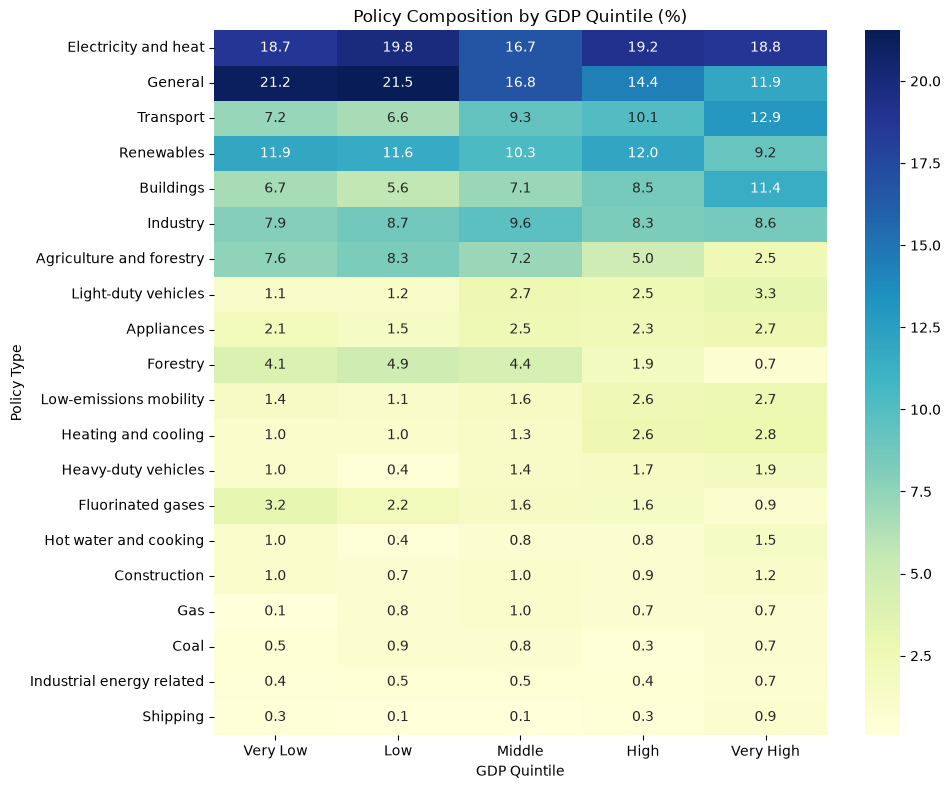

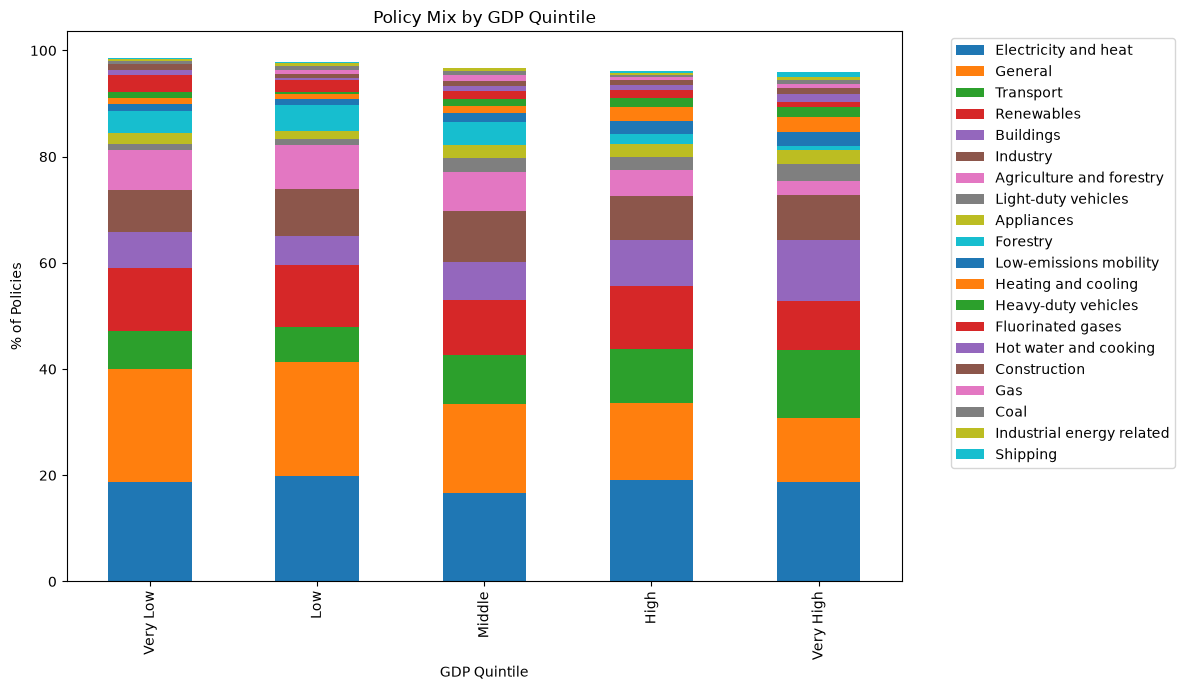

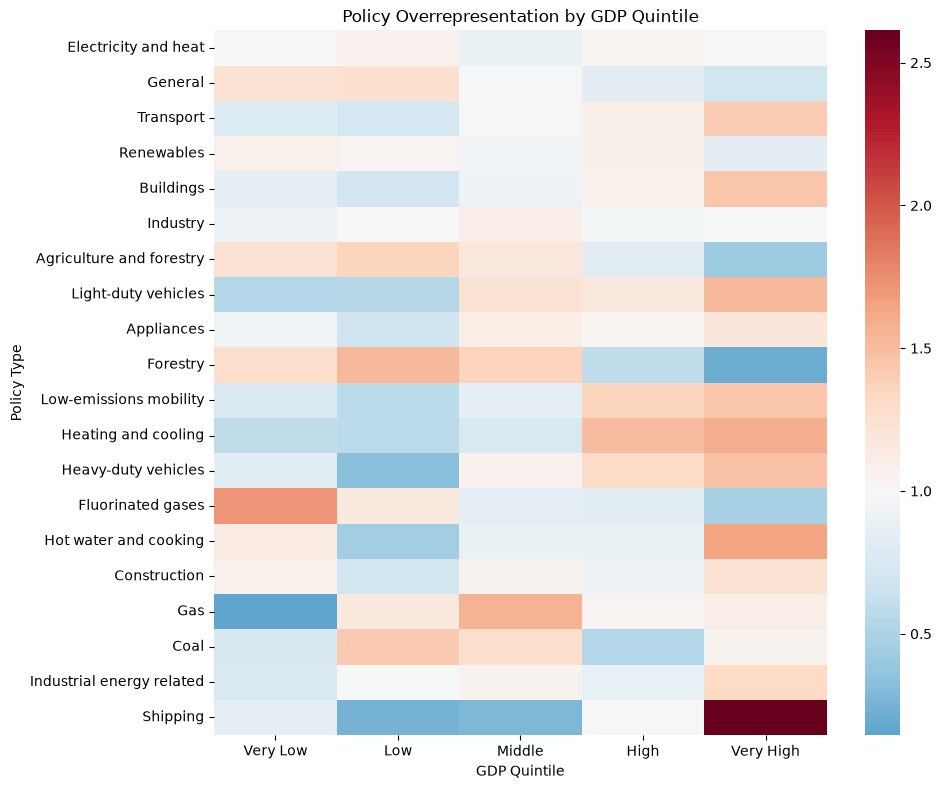

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================
# 1. GDP読み込み
# ==========================

gdp = pd.read_csv(
    "../../data/raw/GDP per capita/db9758b4-95e5-4584-b366-5dd38a5d3769_Data.csv"
)

year_cols = [c for c in gdp.columns if "[YR" in c]

gdp[year_cols] = (
    gdp[year_cols]
    .replace("..", np.nan)
    .apply(pd.to_numeric, errors="coerce")
)

country_gdp = (
    gdp
    .set_index("Country Code")[year_cols]
    .mean(axis=1)
    .reset_index()
)

country_gdp.columns = [
    "country_iso",
    "avg_gdp_pc"
]

# ==========================
# 2. GDPを5分位に分割
# ==========================

country_gdp["gdp_group"] = pd.qcut(
    country_gdp["avg_gdp_pc"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Middle",
        "High",
        "Very High"
    ]
)

# ==========================
# 3. CPDB読み込み
# ==========================

cpdb = pd.read_csv(
    "../../data/raw/cpdb_country_all.csv",
    low_memory=False
)

policy_gdp = cpdb.merge(
    country_gdp,
    on="country_iso",
    how="left"
)

# ==========================
# 4. sector展開
# ==========================

policy_gdp = policy_gdp.dropna(
    subset=["sector", "gdp_group"]
)

policy_gdp["sector"] = (
    policy_gdp["sector"]
    .astype(str)
    .str.replace("&amp;", "&", regex=False)
    .str.split(",")
)

policy_gdp = (
    policy_gdp
    .explode("sector")
    .reset_index(drop=True)
)

policy_gdp["sector"] = (
    policy_gdp["sector"]
    .str.strip()
)

policy_gdp = policy_gdp[
    policy_gdp["sector"] != ""
]

# ==========================
# 5. 集計
# ==========================

counts = (
    policy_gdp
    .groupby(
        ["sector", "gdp_group"]
    )
    .size()
    .unstack(fill_value=0)
)

# GDP階級ごとに100%
shares = counts.div(
    counts.sum(axis=0),
    axis=1
) * 100

# ==========================
# 6. 上位20カテゴリ
# ==========================

top_types = (
    policy_gdp["sector"]
    .value_counts()
    .head(20)
    .index
)

shares_top = shares.loc[top_types]

# ==========================
# 7. ヒートマップ
# ==========================

plt.figure(figsize=(10, 8))

sns.heatmap(
    shares_top,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f"
)

plt.title(
    "Policy Composition by GDP Quintile (%)"
)

plt.xlabel("GDP Quintile")
plt.ylabel("Policy Type")

plt.tight_layout()
plt.show()

# ==========================
# 8. 積み上げ棒グラフ
# ==========================

plot_df = shares_top.T

plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.ylabel("% of Policies")
plt.xlabel("GDP Quintile")

plt.title(
    "Policy Mix by GDP Quintile"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ==========================
# 9. GDPごとの特徴を強調
# ==========================

lift = shares.div(
    shares.mean(axis=1),
    axis=0
)

lift_top = lift.loc[top_types]

plt.figure(figsize=(10, 8))

sns.heatmap(
    lift_top,
    cmap="RdBu_r",
    center=1
)

plt.title(
    "Policy Overrepresentation by GDP Quintile"
)

plt.xlabel("GDP Quintile")
plt.ylabel("Policy Type")

plt.tight_layout()
plt.show()

In [18]:
policy_instrument_counts = (
    policy_gdp["sector"]
    .dropna()
    .astype(str)
    .str.replace("&amp;", "&", regex=False)
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

print(policy_instrument_counts)

sector
Electricity and heat                      2209
General                                   1782
Transport                                 1270
Renewables                                1232
Buildings                                 1091
Industry                                  1032
Agriculture and forestry                   570
Light-duty vehicles                        313
Appliances                                 285
Forestry                                   267
Low-emissions mobility                     266
Heating and cooling                        258
Heavy-duty vehicles                        182
Fluorinated gases                          174
Hot water and cooking                      134
Construction                               125
Gas                                         85
Coal                                        78
Industrial energy related                   67
Shipping                                    62
Waste CH4                                   54
Nuclea

Number of pairs: 37876
Matrix shape: (6, 72)


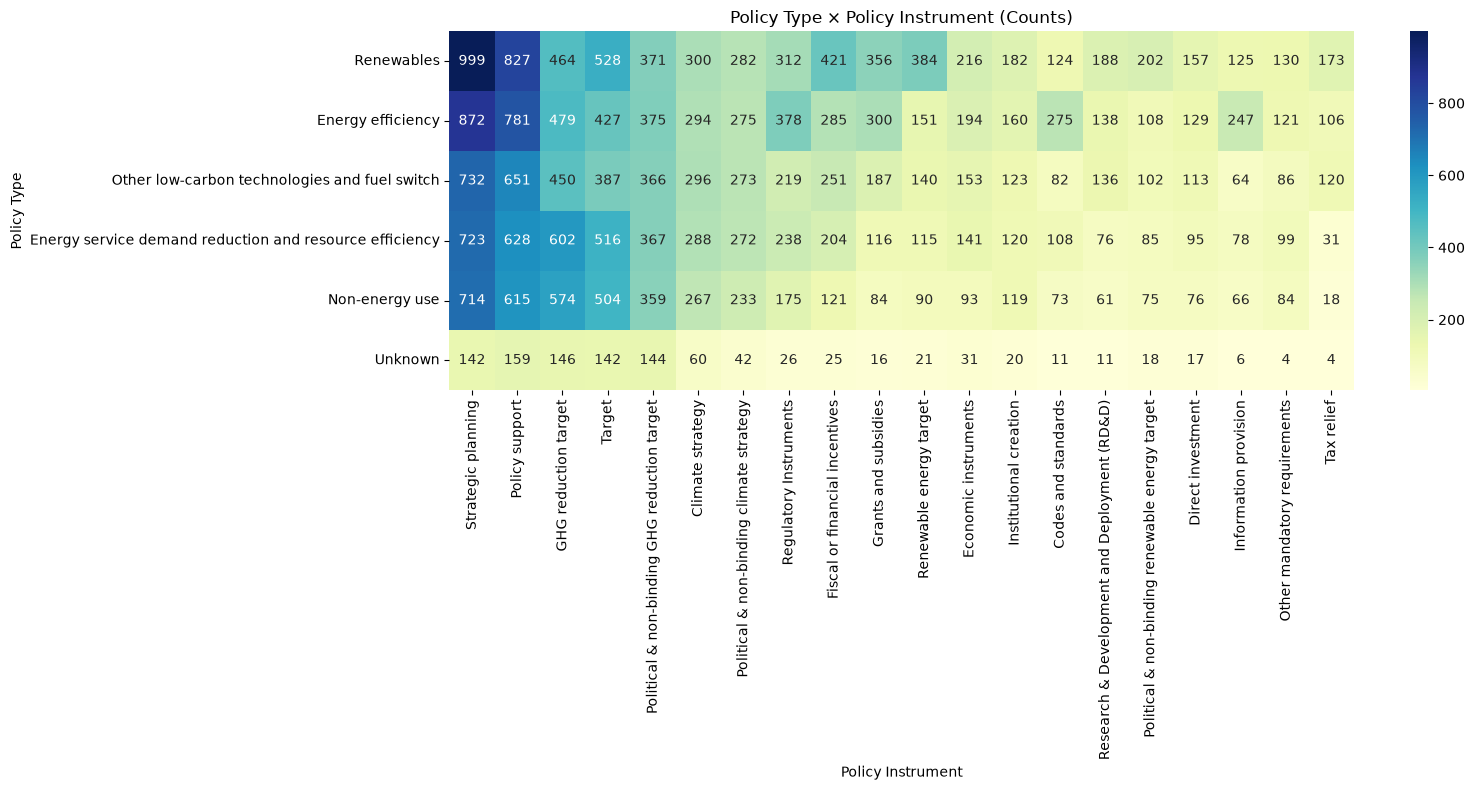

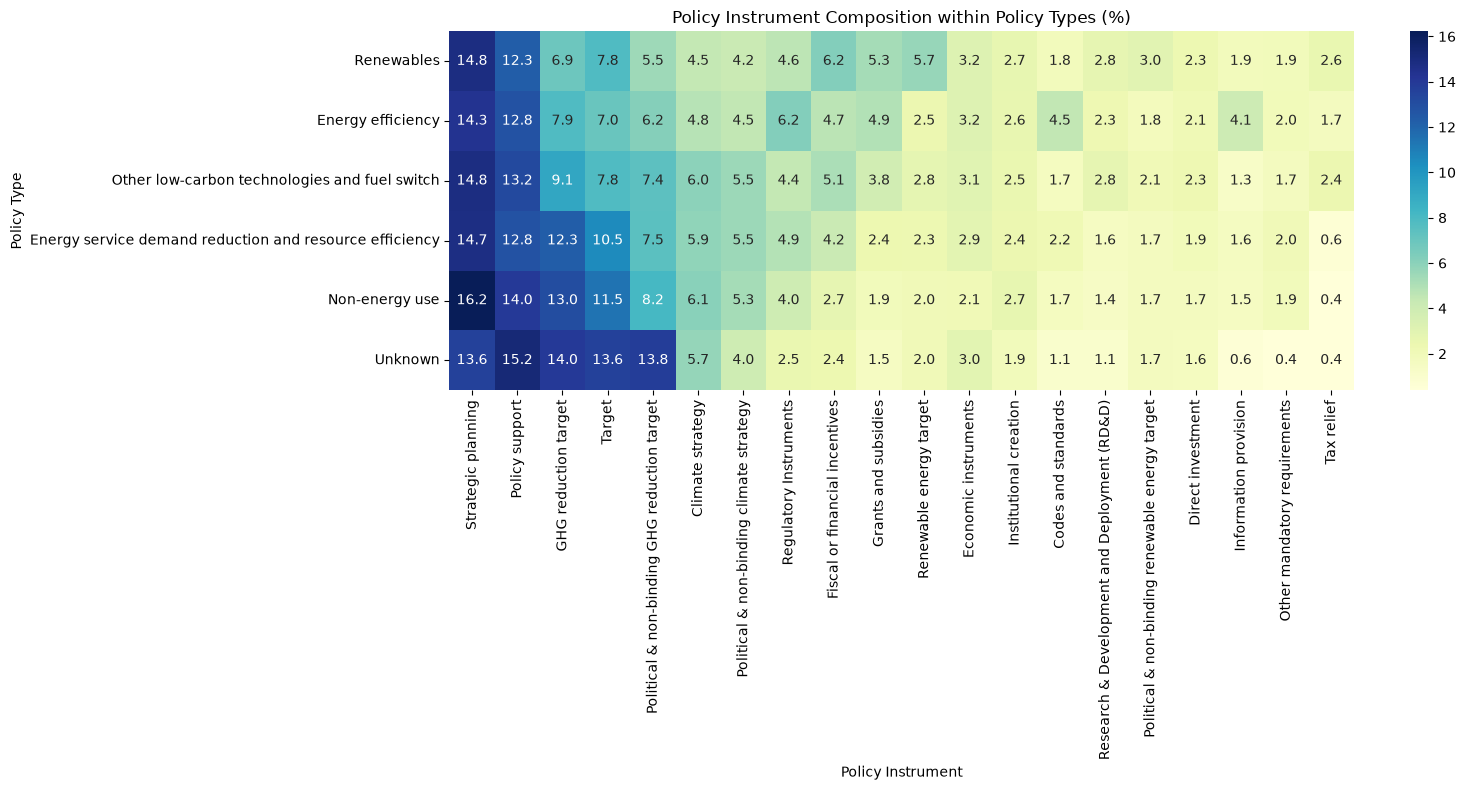

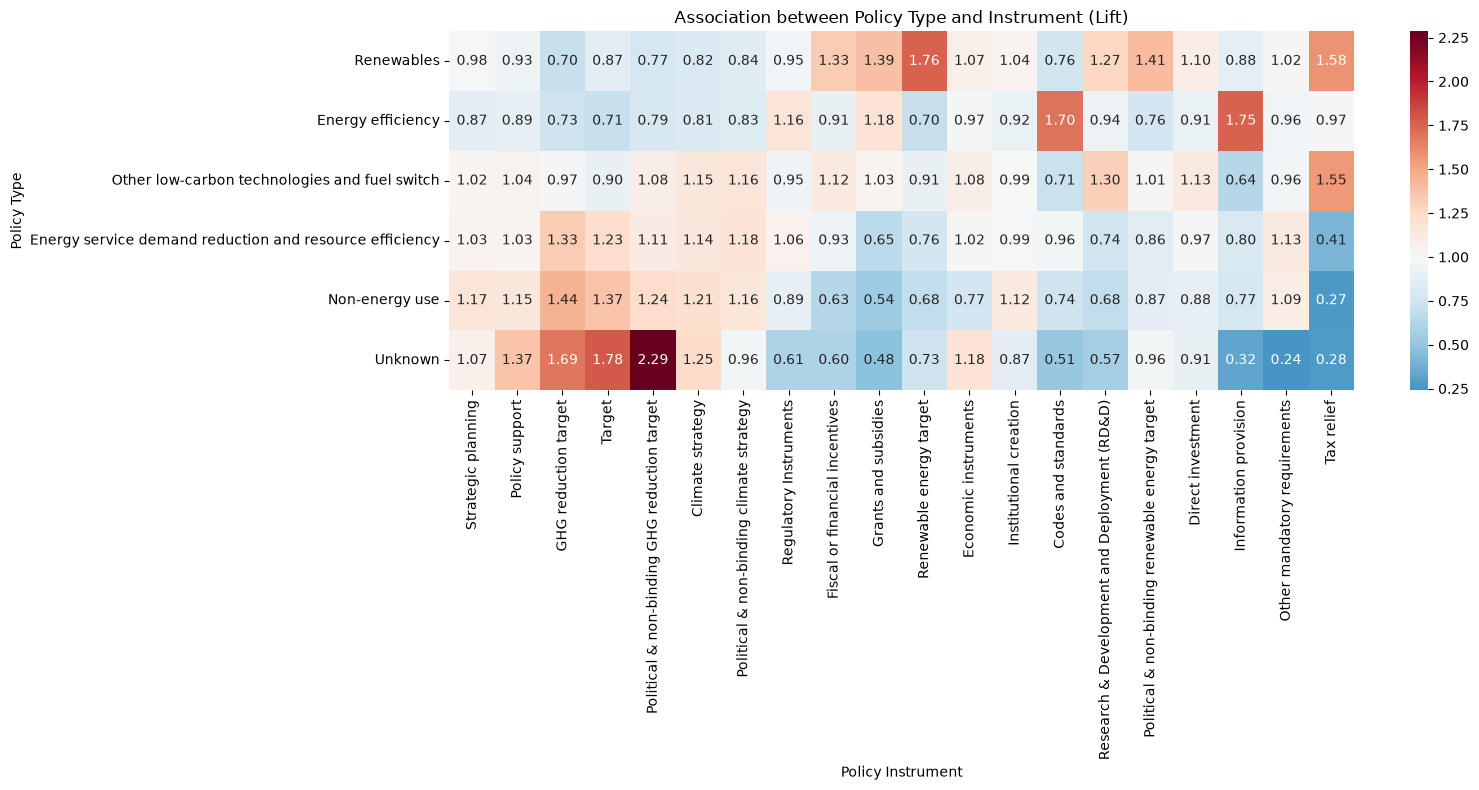


Top 30 strongest associations
                                           policy_type  \
315                                         Renewables   
7                                    Energy efficiency   
325                                         Renewables   
303                                         Renewables   
352                                         Renewables   
3                                    Energy efficiency   
290                                         Renewables   
12                                   Energy efficiency   
314                                         Renewables   
1                                    Energy efficiency   
308                                         Renewables   
172                                     Non-energy use   
40                                   Energy efficiency   
47                                   Energy efficiency   
69                                   Energy efficiency   
402                                      

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. CPDB読み込み
# ==========================================

cpdb = pd.read_csv(
    "../../data/raw/cpdb_country_all.csv",
    low_memory=False
)

df = cpdb.copy()

# ==========================================
# 2. policy_type展開
# ==========================================

df["policy_type"] = (
    df["policy_type"]
    .fillna("")
    .astype(str)
    .str.replace("&amp;", "&", regex=False)
    .str.split(",")
)

# ==========================================
# 3. policy_instrument展開
# ==========================================

df["policy_instrument"] = (
    df["policy_instrument"]
    .fillna("")
    .astype(str)
    .str.replace("&amp;", "&", regex=False)
    .str.split(",")
)

# ==========================================
# 4. type × instrument の全組み合わせ生成
# ==========================================

df = (
    df
    .explode("policy_type")
    .explode("policy_instrument")
    .reset_index(drop=True)
)

df["policy_type"] = (
    df["policy_type"]
    .astype(str)
    .str.strip()
)

df["policy_instrument"] = (
    df["policy_instrument"]
    .astype(str)
    .str.strip()
)

df = df[
    (df["policy_type"] != "")
    & (df["policy_instrument"] != "")
]

print("Number of pairs:", len(df))

# ==========================================
# 5. Type × Instrument マトリクス
# ==========================================

matrix = (
    df
    .groupby(
        ["policy_type", "policy_instrument"],
        observed=False
    )
    .size()
    .unstack(fill_value=0)
)

print("Matrix shape:", matrix.shape)

# ==========================================
# 6. 上位カテゴリ抽出
# ==========================================

top_types = (
    df["policy_type"]
    .value_counts()
    .head(15)
    .index
)

top_instruments = (
    df["policy_instrument"]
    .value_counts()
    .head(20)
    .index
)

matrix_small = matrix.loc[
    top_types,
    top_instruments
]

# ==========================================
# 7. 件数ヒートマップ
# ==========================================

plt.figure(figsize=(16, 8))

sns.heatmap(
    matrix_small,
    cmap="YlGnBu",
    annot=True,
    fmt="g"
)

plt.title(
    "Policy Type × Policy Instrument (Counts)"
)

plt.xlabel("Policy Instrument")
plt.ylabel("Policy Type")

plt.tight_layout()
plt.show()

# ==========================================
# 8. 行方向正規化
# 各政策タイプでどの手段を使うか
# ==========================================

row_share = (
    matrix_small
    .div(matrix_small.sum(axis=1), axis=0)
    * 100
)

plt.figure(figsize=(16, 8))

sns.heatmap(
    row_share,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f"
)

plt.title(
    "Policy Instrument Composition within Policy Types (%)"
)

plt.xlabel("Policy Instrument")
plt.ylabel("Policy Type")

plt.tight_layout()
plt.show()

# ==========================================
# 9. Lift計算
# ==========================================

row_totals = matrix.sum(axis=1)
col_totals = matrix.sum(axis=0)

expected = pd.DataFrame(
    np.outer(row_totals, col_totals)
    / matrix.values.sum(),
    index=matrix.index,
    columns=matrix.columns
)

lift = matrix / expected

lift_small = lift.loc[
    top_types,
    top_instruments
]

# ==========================================
# 10. Liftヒートマップ
# ==========================================

plt.figure(figsize=(16, 8))

sns.heatmap(
    lift_small,
    cmap="RdBu_r",
    center=1,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Association between Policy Type and Instrument (Lift)"
)

plt.xlabel("Policy Instrument")
plt.ylabel("Policy Type")

plt.tight_layout()
plt.show()

# ==========================================
# 11. 強い組み合わせランキング
# ==========================================

lift_long = (
    lift
    .stack()
    .reset_index()
)

lift_long.columns = [
    "policy_type",
    "policy_instrument",
    "lift"
]

count_long = (
    matrix
    .stack()
    .reset_index()
)

count_long.columns = [
    "policy_type",
    "policy_instrument",
    "count"
]

result = lift_long.merge(
    count_long,
    on=["policy_type", "policy_instrument"]
)

# 件数が少なすぎるものを除外
result = result[
    result["count"] >= 20
]

result = result.sort_values(
    "lift",
    ascending=False
)

print("\nTop 30 strongest associations")
print(
    result.head(30)[
        ["policy_type", "policy_instrument", "count", "lift"]
    ]
)